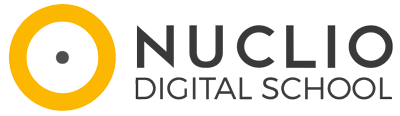

## 0. Importación de librerías

In [2]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Expresiones regulares
import re
from fuzzywuzzy import process

import warnings
warnings.filterwarnings('ignore')

import os
os.getcwd()

c:\Users\matia\anaconda3\envs\Test\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


'c:\\Users\\matia\\Desktop\\Matias\\Estudio\\Análisis de datos\\Nuclio Digital School\\Máster en Data Analytics\\Módulo 6 Data Visualization\\Entregable Data Vis'

### 0.1. Funciones

- Función para facilitar la exploración inicial de datos (2)

In [3]:
def check_df(df, tipo=''):
    if tipo == 'simple':
        print("¿Cuántas filas y columnas hay en el conjunto de datos?")
        num_filas, num_columnas = df.shape
        print("\tHay {:,} filas y {:,} columnas.".format(num_filas, num_columnas))

        print("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display(df.head(2))
        print('\n########################################################################################')
    else:
        print("¿Cuántas filas y columnas hay en el conjunto de datos?")
        num_filas, num_columnas = df.shape
        print("\tHay {:,} filas y {:,} columnas.".format(num_filas, num_columnas))
        print('\n########################################################################################')

        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())
        print('\n########################################################################################')

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())
        print('\n########################################################################################')

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n = 5))
        print('\n########################################################################################')

        print("¿Cuáles son las columnas del conjunto de datos? ¿Cuál es el tipo de datos de cada columna?")
        print(df.dtypes)
        print('\n########################################################################################')

        print("¿Cuántas columnas hay de cada tipo de datos?")
        print(df.dtypes.value_counts())
        print('\n########################################################################################')

        print("¿Cuáles son las variables numéricas?")
        df_numericas = df.select_dtypes(include = 'number')
        columnas_numericas = list(df_numericas.columns)
        print(columnas_numericas)
        print('\n########################################################################################')

        print("¿Cuáles son las variables categóricas?")
        df_categoricas = df.select_dtypes(include = 'object')
        columnas_categoricas = list(df_categoricas.columns)
        print(columnas_categoricas)
        print('\n########################################################################################')

        print("¿Cuántos valores únicos tiene cada columna?")
        print(df.nunique())
        print('\n########################################################################################')

        if len(columnas_numericas)>0:
            print("¿Cuáles son las estadísticas descriptivas básicas de las columnas numéricas?")
            display(df.describe(include = 'number'))
            print('\n########################################################################################')

        if len(columnas_categoricas)>0:
            print("¿Cuáles son las estadísticas descriptivas básicas de las columnas categóricas?")
            display(df.describe(include = 'object'))

- Función para identificar los valores problemáticos (limpieza de datos) (3.1)

In [4]:
def identificacion_valores_problem(df, columnas=[]):
    print('###################################################################################')
    print('3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:')
    print(round((df.isnull().sum()/len(df))*100, 2).sort_values(ascending= False))
    print('###################################################################################')
    print(f'3.1.2. Número de DUPLICADOS totales: {df.duplicated().sum()}')
    print('###################################################################################')
    if len(columnas) > 0:
        print(f'3.1.2. Número de DUPLICADOS parciales según las columnas {columnas}: {df.duplicated(subset=columnas).sum()}')
        print('###################################################################################')
    df_numericas = df.select_dtypes(include = 'number')
    columnas_numericas = list(df_numericas.columns)
    if len(columnas_numericas) > 0:
        print('3.1.3. Columnas numéricas con OUTLIERS')
        for var in columnas_numericas:
            Q1 = df[var].quantile(0.25)
            Q3 = df[var].quantile(0.75)
            limite_inferior = Q1 - 1.5 * (Q3 - Q1)
            limite_superior = Q3 + 1.5 * (Q3 - Q1)
            outliers = df[(df[var] < limite_inferior) | (df[var] > limite_superior)]
            print(f'Número de outliers en la columna "{var}": {outliers.shape[0]}')
        print('###################################################################################')

- Función para detección de outliers (no hace solo un print si no que los guarda en una nueva variable apra luego poder tratarlos)

In [5]:
def deteccion_outliers (df, columna):
    # Calcular Q1, Q3 e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites inferior y superior para detectar outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"Los valores atípicos se definen como aquellos que caen fuera del siguiente rango:")
    print(f"\t - Límite inferior (considerado extremadamente bajo): {limite_inferior:.2f}")
    print(f"\t - Límite superior (considerado extremadamente alto): {limite_superior:.2f}")

    # Identificar los outliers
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    print(f'Número de outliers en la columna "{columna}": {outliers.shape[0]}')
    return outliers

## 1. Carga de datos

In [6]:
df_poblacion = pd.read_excel("data_raw\population_year_country.xlsx", engine="openpyxl")


In [7]:
df_integrado = pd.read_csv("data_raw\df_final_integrado.csv")

In [8]:
df_variaciones = pd.read_excel(
    r"..\Entregable Data Vis\data_raw\vacunas_region_esperanza_vida.xlsx",
    engine="openpyxl"
)

## 2. Exploración inicial

In [9]:
check_df(df_poblacion)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 266 filas y 69 columnas.

########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0



########################################################################################
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
261,Kosovo,XKX,"Population, total",SP.POP.TOTL,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,...,1788274.0,1777568.0,1791019.0,1797086.0,1788891.0,1790151.0,1786079.0,1768096.0,1682668.0,1594353.0
262,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,...,31159379.0,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,40583164.0
263,South Africa,ZAF,"Population, total",SP.POP.TOTL,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,...,56723537.0,57259551.0,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,64007187.0
264,Zambia,ZMB,"Population, total",SP.POP.TOTL,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,...,16399089.0,16914423.0,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,21314956.0
265,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,3809389.0,3930401.0,4055959.0,4185877.0,4320006.0,4458462.0,...,14399013.0,14600294.0,14812482.0,15034452.0,15271368.0,15526888.0,15797210.0,16069056.0,16340822.0,16634373.0



########################################################################################
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
40,China,CHN,"Population, total",SP.POP.TOTL,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
213,"Somalia, Fed. Rep.",SOM,"Population, total",SP.POP.TOTL,2876331.0,2952054.0,3030091.0,3110361.0,3192796.0,3277874.0,...,1.380696e+07,1.434874e+07,1.491663e+07,1.545249e+07,1.603097e+07,1.665119e+07,1.727143e+07,1.780190e+07,1.835862e+07,1.900915e+07
251,United States,USA,"Population, total",SP.POP.TOTL,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,...,3.218151e+08,3.243533e+08,3.266086e+08,3.285296e+08,3.302262e+08,3.315777e+08,3.320998e+08,3.340173e+08,3.368062e+08,3.401110e+08
192,Puerto Rico (US),PRI,"Population, total",SP.POP.TOTL,2358000.0,2399722.0,2450322.0,2504530.0,2554066.0,2594000.0,...,3.535167e+06,3.480432e+06,3.410837e+06,3.290690e+06,3.302691e+06,3.281590e+06,3.262711e+06,3.220137e+06,3.203792e+06,3.203295e+06
66,Ecuador,ECU,"Population, total",SP.POP.TOTL,4590891.0,4722331.0,4859269.0,5001716.0,5149918.0,5303963.0,...,1.626622e+07,1.650514e+07,1.675952e+07,1.704955e+07,1.734002e+07,1.754606e+07,1.768245e+07,1.782390e+07,1.798008e+07,1.813548e+07



########################################################################################
¿Cuáles son las columnas del conjunto de datos? ¿Cuál es el tipo de datos de cada columna?
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2020              float64
2021              float64
2022              float64
2023              float64
2024              float64
Length: 69, dtype: object

########################################################################################
¿Cuántas columnas hay de cada tipo de datos?
float64    65
object      4
Name: count, dtype: int64

########################################################################################
¿Cuáles son las variables numéricas?
['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983'

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,...,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02
mean,1.153986e+08,1.170032e+08,1.191639e+08,1.218340e+08,1.245281e+08,1.272539e+08,1.300993e+08,1.329525e+08,1.358805e+08,1.389068e+08,...,3.001948e+08,3.040206e+08,3.078413e+08,3.115874e+08,3.152613e+08,3.187768e+08,3.219350e+08,3.250893e+08,3.283978e+08,3.318713e+08
std,3.616512e+08,3.661333e+08,3.727667e+08,3.813673e+08,3.900147e+08,3.987681e+08,4.079973e+08,4.172128e+08,4.266920e+08,4.365296e+08,...,9.336943e+08,9.447157e+08,9.557272e+08,9.664012e+08,9.767615e+08,9.865558e+08,9.952478e+08,1.003664e+09,1.012445e+09,1.021698e+09
min,2.715000e+03,2.970000e+03,3.264000e+03,3.584000e+03,3.922000e+03,4.282000e+03,4.664000e+03,5.071000e+03,5.500000e+03,5.631000e+03,...,1.095400e+04,1.093000e+04,1.086900e+04,1.075100e+04,1.058100e+04,1.039900e+04,1.019400e+04,9.992000e+03,9.816000e+03,9.646000e+03
25%,5.152028e+05,5.255230e+05,5.363018e+05,5.475875e+05,5.593638e+05,5.675750e+05,5.711695e+05,5.779525e+05,5.825170e+05,5.861185e+05,...,1.786457e+06,1.777568e+06,1.791019e+06,1.797086e+06,1.788891e+06,1.790151e+06,1.786079e+06,1.803545e+06,1.827816e+06,1.824359e+06
50%,3.659633e+06,3.747132e+06,3.831900e+06,3.919710e+06,4.010150e+06,4.102976e+06,4.198738e+06,4.297792e+06,4.396290e+06,4.503420e+06,...,1.035808e+07,1.032545e+07,1.025915e+07,1.028382e+07,1.042338e+07,1.069786e+07,1.050577e+07,1.048694e+07,1.064485e+07,1.090503e+07
75%,2.686293e+07,2.761326e+07,2.837302e+07,2.915448e+07,2.995223e+07,3.075921e+07,3.147516e+07,3.203946e+07,3.247057e+07,3.277149e+07,...,6.022960e+07,6.011522e+07,6.000225e+07,6.014866e+07,5.972908e+07,6.097280e+07,6.283041e+07,6.471182e+07,6.661761e+07,6.855165e+07
max,3.021513e+09,3.062768e+09,3.117372e+09,3.184063e+09,3.251253e+09,3.318998e+09,3.389087e+09,3.459015e+09,3.530704e+09,3.604816e+09,...,7.441677e+09,7.528880e+09,7.614523e+09,7.697234e+09,7.778009e+09,7.854748e+09,7.920515e+09,7.989545e+09,8.064058e+09,8.141809e+09



########################################################################################
¿Cuáles son las estadísticas descriptivas básicas de las columnas categóricas?


,Country Name,Country Code,Indicator Name,Indicator Code
count,266,266,266,266
unique,266,266,1,1
top,Aruba,ABW,"Population, total",SP.POP.TOTL
freq,1,1,266,266


In [10]:
columnas_anos = [col for col in df_poblacion.columns if col.isdigit()]

In [11]:
columnas_anos

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [12]:
df_pob_melt = df_poblacion.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=columnas_anos,
    var_name="Year",
    value_name="Population"
)


In [13]:
df_pob_melt_ordenado = df_pob_melt.sort_values(["Country Name","Year"])

In [14]:
df_pob_melt_ordenado_2 = df_pob_melt_ordenado.rename(columns={
    "Country Name": "Entity",
    "Country Code": "Code"
})


In [15]:
df_pob_melt_ordenado_2.head()

,Entity,Code,Year,Population
2,Afghanistan,AFG,1960,9035043.0
268,Afghanistan,AFG,1961,9214083.0
534,Afghanistan,AFG,1962,9404406.0
800,Afghanistan,AFG,1963,9604487.0
1066,Afghanistan,AFG,1964,9814318.0


In [16]:
df_pob_melt_ordenado_2["Year"] = df_pob_melt_ordenado_2["Year"].astype(str)


In [17]:
df_integrado["Year"] = df_integrado["Year"].astype(str)

In [18]:
check_df(df_integrado)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 2,058 filas y 49 columnas.

########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region
0,Argentina,ARG,1980,68.5642,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina
1,Argentina,ARG,1981,68.9762,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina
2,Argentina,ARG,1982,68.9368,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina
3,Argentina,ARG,1983,69.2668,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina
4,Argentina,ARG,1984,69.1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina



########################################################################################
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region
2053,Venezuela,VEN,2017,71.9430,2.24,2.790584,272.0,5789.0,973.0,511.0,...,66.0,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina
2054,Venezuela,VEN,2018,71.9788,2.21,3.211418,260.0,6036.0,1022.0,523.0,...,60.0,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina
2055,Venezuela,VEN,2019,72.1614,2.10,2.471101,254.0,6313.0,1119.0,552.0,...,64.0,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina
2056,Venezuela,VEN,2020,71.0949,NaN,NaN,NaN,NaN,NaN,NaN,...,54.0,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina
2057,Venezuela,VEN,2021,70.5536,NaN,NaN,NaN,NaN,NaN,NaN,...,56.0,59.0,68.0,0.0,50.0,68.0,0.0,75.0,56.0,América Latina



########################################################################################
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region
1552,Poland,POL,2020,76.9424,NaN,NaN,NaN,NaN,NaN,NaN,...,90.0,99.0,80.0,62.0,91.0,80.0,NaN,NaN,90.0,Europa Occidental
150,Belize,BLZ,2004,69.2270,8.8400,2.282006,3.0,25.0,7.0,12.0,...,97.0,NaN,97.0,NaN,97.0,97.0,NaN,NaN,97.0,América Latina
1307,Nicaragua,NIC,1985,56.5008,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,59.0,NaN,88.0,NaN,NaN,NaN,39.0,América Latina
1583,Portugal,PRT,2009,79.7706,8.6500,6.463876,44.0,4473.0,1064.0,128.0,...,96.0,NaN,95.0,NaN,96.0,95.0,NaN,NaN,96.0,Europa Occidental
2001,Uruguay,URY,2007,76.4981,15.7926,3.636779,24.0,1144.0,294.0,116.0,...,94.0,NaN,96.0,NaN,94.0,96.0,NaN,NaN,94.0,América Latina



########################################################################################
¿Cuáles son las columnas del conjunto de datos? ¿Cuál es el tipo de datos de cada columna?
Entity                                                                                       object
Code                                                                                         object
Year                                                                                         object
Period life expectancy at birth - Sex: all - Age: 0                                         float64
Age-standardized suicide rate - Sex: both sexes                                             float64
Domestic general government health expenditure (% of GDP)                                   float64
Deaths - Meningitis - Sex: Both - Age: All Ages (Number)                                    float64
Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number)       float64
Deaths - Parkinson'

,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),Deaths - Malaria - Sex: Both - Age: All Ages (Number),Deaths - Drowning - Sex: Both - Age: All Ages (Number),Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number),...,HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized)
count,2058.000000,980.000000,980.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,902.000000,1128.000000,334.000000,1949.000000,469.000000,1987.000000,1488.000000,322.000000,240.000000,1979.000000
mean,73.428442,10.076658,4.722844,293.870748,6115.191837,1305.415646,864.026531,78.431973,564.582993,2957.569388,...,85.113082,89.237589,91.203593,83.607491,84.140725,86.351283,89.487231,76.869565,58.025000,85.029308
std,6.175050,6.551987,2.027042,748.544916,9882.644469,2073.428822,2127.600218,341.981959,1266.236411,9312.281797,...,18.412961,13.891656,15.365825,18.166873,18.776162,16.229174,11.489177,21.041312,34.648374,17.388999
min,46.018500,1.600000,0.293856,1.000000,18.000000,3.000000,1.000000,0.000000,2.000000,2.000000,...,1.000000,2.000000,3.000000,3.000000,0.000000,3.000000,8.000000,0.000000,0.000000,3.000000
25%,70.235375,5.570000,3.054545,30.000000,633.500000,145.000000,19.250000,0.000000,75.000000,125.250000,...,83.000000,88.000000,92.000000,79.000000,82.000000,83.000000,87.000000,70.000000,25.250000,81.000000
50%,74.229000,8.980000,4.599281,81.000000,2052.500000,456.500000,135.000000,0.000000,179.000000,360.500000,...,92.000000,94.000000,97.000000,91.000000,91.000000,92.000000,93.000000,84.000000,72.500000,92.000000
75%,77.796375,12.591400,6.319801,267.000000,5551.750000,1219.750000,589.500000,4.000000,569.750000,1237.750000,...,96.000000,97.000000,98.750000,96.000000,94.000000,96.000000,96.000000,90.000000,88.000000,96.000000
max,83.987200,40.852400,9.276339,8388.000000,54594.000000,12875.000000,16573.000000,4212.000000,10778.000000,69640.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000



########################################################################################
¿Cuáles son las estadísticas descriptivas básicas de las columnas categóricas?


,Entity,Code,Year,Region
count,2058,2058,2058,2058
unique,49,49,42,2
top,Argentina,ARG,1980,Europa Occidental
freq,42,42,49,1050


In [19]:
df_integrado["Entity"].unique()

array(['Argentina', 'Austria', 'Belgium', 'Belize', 'Bolivia', 'Brazil',
       'Chile', 'Colombia', 'Costa Rica', 'Czechia', 'Denmark',
       'Dominican Republic', 'Ecuador', 'El Salvador', 'Estonia',
       'Finland', 'France', 'Germany', 'Greece', 'Guatemala', 'Guyana',
       'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Ireland', 'Italy',
       'Jamaica', 'Luxembourg', 'Mexico', 'Netherlands', 'Nicaragua',
       'Norway', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal',
       'Slovakia', 'Slovenia', 'Spain', 'Suriname', 'Sweden',
       'Switzerland', 'Trinidad and Tobago', 'Turkey', 'United Kingdom',
       'Uruguay', 'Venezuela'], dtype=object)

In [20]:
df_integrado["Entity"].nunique()

49

In [21]:
df_integrado["Region"].unique()

array(['América Latina', 'Europa Occidental'], dtype=object)

In [22]:
df_integrado["Code"].unique()

array(['ARG', 'AUT', 'BEL', 'BLZ', 'BOL', 'BRA', 'CHL', 'COL', 'CRI',
       'CZE', 'DNK', 'DOM', 'ECU', 'SLV', 'EST', 'FIN', 'FRA', 'DEU',
       'GRC', 'GTM', 'GUY', 'HTI', 'HND', 'HUN', 'ISL', 'IRL', 'ITA',
       'JAM', 'LUX', 'MEX', 'NLD', 'NIC', 'NOR', 'PAN', 'PRY', 'PER',
       'POL', 'PRT', 'SVK', 'SVN', 'ESP', 'SUR', 'SWE', 'CHE', 'TTO',
       'TUR', 'GBR', 'URY', 'VEN'], dtype=object)

In [23]:
df_integrado["Code"].nunique()

49

In [24]:
df_integrado["Year"].unique()

array(['1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021'], dtype=object)

In [25]:
df_integrado.isnull().sum()


Entity                                                                                         0
Code                                                                                           0
Year                                                                                           0
Period life expectancy at birth - Sex: all - Age: 0                                            0
Age-standardized suicide rate - Sex: both sexes                                             1078
Domestic general government health expenditure (% of GDP)                                   1078
Deaths - Meningitis - Sex: Both - Age: All Ages (Number)                                     588
Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number)        588
Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)                            588
Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number)                       588
Deaths - Malaria - Sex: Both -

## Agregamos datos de Población por año y paises al df_integrado

In [26]:
df_integrado_pob = df_integrado.merge(
    df_pob_melt_ordenado_2[["Code", "Year", "Population"]],
    on=["Code", "Year"],
    how="inner" )


In [27]:
df_integrado_pob

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
0,Argentina,ARG,1980,68.5642,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina,28011596.0
1,Argentina,ARG,1981,68.9762,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina,28463959.0
2,Argentina,ARG,1982,68.9368,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina,28924262.0
3,Argentina,ARG,1983,69.2668,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina,29391332.0
4,Argentina,ARG,1984,69.1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina,29863093.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,2.24,2.790584,272.0,5789.0,973.0,511.0,...,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0
2054,Venezuela,VEN,2018,71.9788,2.21,3.211418,260.0,6036.0,1022.0,523.0,...,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0
2055,Venezuela,VEN,2019,72.1614,2.10,2.471101,254.0,6313.0,1119.0,552.0,...,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0
2056,Venezuela,VEN,2020,71.0949,NaN,NaN,NaN,NaN,NaN,NaN,...,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0


## Análisis exploratorio del nuevo DF con datos de población incluidos

In [28]:
check_df(df_integrado_pob)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 2,058 filas y 50 columnas.

########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
0,Argentina,ARG,1980,68.5642,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina,28011596.0
1,Argentina,ARG,1981,68.9762,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina,28463959.0
2,Argentina,ARG,1982,68.9368,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina,28924262.0
3,Argentina,ARG,1983,69.2668,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina,29391332.0
4,Argentina,ARG,1984,69.1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina,29863093.0



########################################################################################
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
2053,Venezuela,VEN,2017,71.9430,2.24,2.790584,272.0,5789.0,973.0,511.0,...,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0
2054,Venezuela,VEN,2018,71.9788,2.21,3.211418,260.0,6036.0,1022.0,523.0,...,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0
2055,Venezuela,VEN,2019,72.1614,2.10,2.471101,254.0,6313.0,1119.0,552.0,...,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0
2056,Venezuela,VEN,2020,71.0949,NaN,NaN,NaN,NaN,NaN,NaN,...,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0
2057,Venezuela,VEN,2021,70.5536,NaN,NaN,NaN,NaN,NaN,NaN,...,59.0,68.0,0.0,50.0,68.0,0.0,75.0,56.0,América Latina,28237826.0



########################################################################################
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),...,IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
1503,Peru,PER,2013,74.9668,3.1900,2.658441,163.0,5484.0,1292.0,1257.0,...,NaN,85.0,85.0,71.0,85.0,86.0,64.0,88.0,América Latina,29817919.0
345,Costa Rica,CRI,1989,76.2626,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,77.0,NaN,86.0,77.0,NaN,NaN,86.0,América Latina,3043827.0
67,Austria,AUT,2005,79.5210,13.2843,6.994200,37.0,3197.0,796.0,7.0,...,NaN,75.0,NaN,86.0,75.0,NaN,NaN,86.0,Europa Occidental,8227829.0
1983,Uruguay,URY,1989,73.0020,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,82.0,NaN,88.0,82.0,NaN,NaN,88.0,América Latina,3086255.0
132,Belize,BLZ,1986,69.7037,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,85.0,NaN,84.0,NaN,NaN,NaN,82.0,América Latina,167554.0



########################################################################################
¿Cuáles son las columnas del conjunto de datos? ¿Cuál es el tipo de datos de cada columna?
Entity                                                                                       object
Code                                                                                         object
Year                                                                                         object
Period life expectancy at birth - Sex: all - Age: 0                                         float64
Age-standardized suicide rate - Sex: both sexes                                             float64
Domestic general government health expenditure (% of GDP)                                   float64
Deaths - Meningitis - Sex: Both - Age: All Ages (Number)                                    float64
Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number)       float64
Deaths - Parkinson'

,Period life expectancy at birth - Sex: all - Age: 0,Age-standardized suicide rate - Sex: both sexes,Domestic general government health expenditure (% of GDP),Deaths - Meningitis - Sex: Both - Age: All Ages (Number),Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number),Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number),Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number),Deaths - Malaria - Sex: Both - Age: All Ages (Number),Deaths - Drowning - Sex: Both - Age: All Ages (Number),Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number),...,Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Population
count,2058.000000,980.000000,980.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1128.000000,334.000000,1949.000000,469.000000,1987.000000,1488.000000,322.000000,240.000000,1979.000000,2.058000e+03
mean,73.428442,10.076658,4.722844,293.870748,6115.191837,1305.415646,864.026531,78.431973,564.582993,2957.569388,...,89.237589,91.203593,83.607491,84.140725,86.351283,89.487231,76.869565,58.025000,85.029308,2.096728e+07
std,6.175050,6.551987,2.027042,748.544916,9882.644469,2073.428822,2127.600218,341.981959,1266.236411,9312.281797,...,13.891656,15.365825,18.166873,18.776162,16.229174,11.489177,21.041312,34.648374,17.388999,3.196549e+07
min,46.018500,1.600000,0.293856,1.000000,18.000000,3.000000,1.000000,0.000000,2.000000,2.000000,...,2.000000,3.000000,3.000000,0.000000,3.000000,8.000000,0.000000,0.000000,3.000000,1.450620e+05
25%,70.235375,5.570000,3.054545,30.000000,633.500000,145.000000,19.250000,0.000000,75.000000,125.250000,...,88.000000,92.000000,79.000000,82.000000,83.000000,87.000000,70.000000,25.250000,81.000000,3.884648e+06
50%,74.229000,8.980000,4.599281,81.000000,2052.500000,456.500000,135.000000,0.000000,179.000000,360.500000,...,94.000000,97.000000,91.000000,91.000000,92.000000,93.000000,84.000000,72.500000,92.000000,8.552596e+06
75%,77.796375,12.591400,6.319801,267.000000,5551.750000,1219.750000,589.500000,4.000000,569.750000,1237.750000,...,97.000000,98.750000,96.000000,94.000000,96.000000,96.000000,90.000000,88.000000,96.000000,2.334326e+07
max,83.987200,40.852400,9.276339,8388.000000,54594.000000,12875.000000,16573.000000,4212.000000,10778.000000,69640.000000,...,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,2.095503e+08



########################################################################################
¿Cuáles son las estadísticas descriptivas básicas de las columnas categóricas?


,Entity,Code,Year,Region
count,2058,2058,2058,2058
unique,49,49,42,2
top,Argentina,ARG,1980,Europa Occidental
freq,42,42,49,1050


In [29]:
df_integrado_pob.columns

Index(['Entity', 'Code', 'Year',
       'Period life expectancy at birth - Sex: all - Age: 0',
       'Age-standardized suicide rate - Sex: both sexes',
       'Domestic general government health expenditure (% of GDP)',
       'Deaths - Meningitis - Sex: Both - Age: All Ages (Number)',
       'Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number)',
       'Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)',
       'Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number)',
       'Deaths - Malaria - Sex: Both - Age: All Ages (Number)',
       'Deaths - Drowning - Sex: Both - Age: All Ages (Number)',
       'Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number)',
       'Deaths - Maternal disorders - Sex: Both - Age: All Ages (Number)',
       'Deaths - HIV/AIDS - Sex: Both - Age: All Ages (Number)',
       'Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)',
       'Deaths - Tuberculosis - Sex:

In [30]:
columnas_eliminar = ["Age-standardized suicide rate - Sex: both sexes",
 "Domestic general government health expenditure (% of GDP)",
 "Deaths - Meningitis - Sex: Both - Age: All Ages (Number)",
 "Deaths - Alzheimer's disease and other dementias - Sex: Both - Age: All Ages (Number)",
 "Deaths - Parkinson's disease - Sex: Both - Age: All Ages (Number)",
 "Deaths - Nutritional deficiencies - Sex: Both - Age: All Ages (Number)",
 "Deaths - Malaria - Sex: Both - Age: All Ages (Number)",
 "Deaths - Drowning - Sex: Both - Age: All Ages (Number)",
 "Deaths - Interpersonal violence - Sex: Both - Age: All Ages (Number)",
 "Deaths - Maternal disorders - Sex: Both - Age: All Ages (Number)",
 "Deaths - HIV/AIDS - Sex: Both - Age: All Ages (Number)",
 "Deaths - Drug use disorders - Sex: Both - Age: All Ages (Number)",
 "Deaths - Tuberculosis - Sex: Both - Age: All Ages (Number)",
 "Deaths - Cardiovascular diseases - Sex: Both - Age: All Ages (Number)",
 "Deaths - Lower respiratory infections - Sex: Both - Age: All Ages (Number)",
 "Deaths - Neonatal disorders - Sex: Both - Age: All Ages (Number)",
 "Deaths - Alcohol use disorders - Sex: Both - Age: All Ages (Number)",
 "Deaths - Self-harm - Sex: Both - Age: All Ages (Number)",
 "Deaths - Exposure to forces of nature - Sex: Both - Age: All Ages (Number)",
 "Deaths - Diarrheal diseases - Sex: Both - Age: All Ages (Number)",
 "Deaths - Environmental heat and cold exposure - Sex: Both - Age: All Ages (Number)",
 "Deaths - Neoplasms - Sex: Both - Age: All Ages (Number)",
 "Deaths - Conflict and terrorism - Sex: Both - Age: All Ages (Number)",
 "Deaths - Diabetes mellitus - Sex: Both - Age: All Ages (Number)",
 "Deaths - Chronic kidney disease - Sex: Both - Age: All Ages (Number)",
 "Deaths - Poisonings - Sex: Both - Age: All Ages (Number)",
 "Deaths - Protein-energy malnutrition - Sex: Both - Age: All Ages (Number)",
 "Deaths - Road injuries - Sex: Both - Age: All Ages (Number)",
 "Deaths - Chronic respiratory diseases - Sex: Both - Age: All Ages (Number)",
 "Deaths - Cirrhosis and other chronic liver diseases - Sex: Both - Age: All Ages (Number)",
 "Deaths - Digestive diseases - Sex: Both - Age: All Ages (Number)",
 "Deaths - Fire, heat, and hot substances - Sex: Both - Age: All Ages (Number)",
 "Deaths - Acute hepatitis - Sex: Both - Age: All Ages (Number)" ]

In [31]:
df_filtrado_vacunas = df_integrado_pob.drop(columns=columnas_eliminar, errors="ignore")


In [32]:
df_filtrado_vacunas.head()

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
0,Argentina,ARG,1980,68.5642,62.0,NaN,NaN,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina,28011596.0
1,Argentina,ARG,1981,68.9762,70.0,NaN,NaN,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina,28463959.0
2,Argentina,ARG,1982,68.9368,77.0,NaN,NaN,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina,28924262.0
3,Argentina,ARG,1983,69.2668,70.0,NaN,NaN,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina,29391332.0
4,Argentina,ARG,1984,69.1953,78.0,NaN,NaN,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina,29863093.0


In [33]:
df_filtrado_vacunas.isnull().sum()

Entity                                                    0
Code                                                      0
Year                                                      0
Period life expectancy at birth - Sex: all - Age: 0       0
BCG (% of one-year-olds immunized)                      736
HepB3 (% of one-year-olds immunized)                   1156
Hib3 (% of one-year-olds immunized)                     930
IPV1 (% of one-year-olds immunized)                    1724
MCV1 (% of one-year-olds immunized)                     109
PCV3 (% of one-year-olds immunized)                    1589
Pol3 (% of one-year-olds immunized)                      71
RCV1 (% of one-year-olds immunized)                     570
RotaC (% of one-year-olds immunized)                   1736
YFV (% of one-year-olds immunized)                     1818
DTP3 (% of one-year-olds immunized)                      79
Region                                                    0
Population                              

In [34]:
vacunas = [
    'BCG (% of one-year-olds immunized)',
    'HepB3 (% of one-year-olds immunized)',
    'Hib3 (% of one-year-olds immunized)',
    'IPV1 (% of one-year-olds immunized)',
    'MCV1 (% of one-year-olds immunized)',
    'PCV3 (% of one-year-olds immunized)',
    'Pol3 (% of one-year-olds immunized)',
    'RCV1 (% of one-year-olds immunized)',
    'RotaC (% of one-year-olds immunized)',
    'YFV (% of one-year-olds immunized)',
    'DTP3 (% of one-year-olds immunized)'
]


In [35]:
df_trat_nulos = df_filtrado_vacunas.copy()

In [36]:
df_sin_nulos = df_trat_nulos.dropna(subset=vacunas, how="all")


In [37]:
df_sin_nulos

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
0,Argentina,ARG,1980,68.5642,62.0,NaN,NaN,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina,28011596.0
1,Argentina,ARG,1981,68.9762,70.0,NaN,NaN,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina,28463959.0
2,Argentina,ARG,1982,68.9368,77.0,NaN,NaN,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina,28924262.0
3,Argentina,ARG,1983,69.2668,70.0,NaN,NaN,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina,29391332.0
4,Argentina,ARG,1984,69.1953,78.0,NaN,NaN,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina,29863093.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,94.0,66.0,66.0,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0
2054,Venezuela,VEN,2018,71.9788,92.0,60.0,60.0,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0
2055,Venezuela,VEN,2019,72.1614,91.0,64.0,64.0,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0
2056,Venezuela,VEN,2020,71.0949,82.0,54.0,54.0,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0


In [38]:
df_sin_nulos.isnull().sum()

Entity                                                    0
Code                                                      0
Year                                                      0
Period life expectancy at birth - Sex: all - Age: 0       0
BCG (% of one-year-olds immunized)                      668
HepB3 (% of one-year-olds immunized)                   1088
Hib3 (% of one-year-olds immunized)                     862
IPV1 (% of one-year-olds immunized)                    1656
MCV1 (% of one-year-olds immunized)                      41
PCV3 (% of one-year-olds immunized)                    1521
Pol3 (% of one-year-olds immunized)                       3
RCV1 (% of one-year-olds immunized)                     502
RotaC (% of one-year-olds immunized)                   1668
YFV (% of one-year-olds immunized)                     1750
DTP3 (% of one-year-olds immunized)                      11
Region                                                    0
Population                              

In [39]:
df_sin_nulos["Year"] = pd.to_numeric(df_sin_nulos["Year"], errors="coerce")
df_sin_nulos



,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population
0,Argentina,ARG,1980,68.5642,62.0,NaN,NaN,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina,28011596.0
1,Argentina,ARG,1981,68.9762,70.0,NaN,NaN,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina,28463959.0
2,Argentina,ARG,1982,68.9368,77.0,NaN,NaN,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina,28924262.0
3,Argentina,ARG,1983,69.2668,70.0,NaN,NaN,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina,29391332.0
4,Argentina,ARG,1984,69.1953,78.0,NaN,NaN,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina,29863093.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,94.0,66.0,66.0,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0
2054,Venezuela,VEN,2018,71.9788,92.0,60.0,60.0,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0
2055,Venezuela,VEN,2019,72.1614,91.0,64.0,64.0,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0
2056,Venezuela,VEN,2020,71.0949,82.0,54.0,54.0,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0


In [40]:
df_filtro_years = df_sin_nulos[df_sin_nulos["Year"] > 1980]


In [41]:
df_filtro_years.groupby("Code").describe()

Year                                                               \
     count    mean        std     min      25%     50%      75%     max   
Code                                                                      
ARG   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
AUT   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
BEL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
BLZ   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
BOL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
BRA   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
CHE   36.0  2003.5  10.535654  1986.0  1994.75  2003.5  2012.25  2021.0   
CHL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
COL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
CRI   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
CZE   29.0  2007.0   8.514693  1993.0  2000.00  2007.0  2014.00  2021.0   
DEU   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
DNK   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
DOM   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
ECU   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
ESP   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
EST   29.0  2007.0   8.514693  1993.0  2000.00  2007.0  2014.00  2021.0   
FIN   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
FRA   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
GBR   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
GRC   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
GTM   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
GUY   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
HND   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
HTI   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
HUN   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
IRL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
ISL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
ITA   39.0  2002.0  11.401754  1983.0  1992.50  2002.0  2011.50  2021.0   
JAM   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
LUX   39.0  2002.0  11.401754  1983.0  1992.50  2002.0  2011.50  2021.0   
MEX   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
NIC   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
NLD   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
NOR   39.0  2002.0  11.401754  1983.0  1992.50  2002.0  2011.50  2021.0   
PAN   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
PER   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
POL   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
PRT   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
PRY   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
SLV   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
SUR   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
SVK   28.0  2007.5   8.225975  1994.0  2000.75  2007.5  2014.25  2021.0   
SVN   30.0  2006.5   8.803408  1992.0  1999.25  2006.5  2013.75  2021.0   
SWE   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
TTO   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
TUR   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
URY   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   
VEN   41.0  2001.0  11.979149  1981.0  1991.00  2001.0  2011.00  2021.0   

     Period life expectancy at birth - Sex: all - Age: 0             ...  \
                             

In [42]:
df_analisis = df_sin_nulos.copy()

In [43]:
df_analisis["pobl_con_dato"] = df_analisis.groupby(["Region", "Year"])["Population"].transform("sum")

In [44]:
df_analisis["Ponderacion poblacion en región"] = df_analisis["Population"] / df_analisis["pobl_con_dato"] 

In [45]:
df_analisis

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population,pobl_con_dato,Ponderacion poblacion en región
0,Argentina,ARG,1980,68.5642,62.0,NaN,NaN,NaN,61.0,NaN,33.0,NaN,NaN,NaN,44.0,América Latina,28011596.0,345355646.0,0.081109
1,Argentina,ARG,1981,68.9762,70.0,NaN,NaN,NaN,77.0,NaN,40.0,NaN,NaN,NaN,49.0,América Latina,28463959.0,353169711.0,0.080596
2,Argentina,ARG,1982,68.9368,77.0,NaN,NaN,NaN,67.0,NaN,48.0,NaN,NaN,NaN,58.0,América Latina,28924262.0,361006616.0,0.080121
3,Argentina,ARG,1983,69.2668,70.0,NaN,NaN,NaN,67.0,NaN,79.0,NaN,NaN,NaN,61.0,América Latina,29391332.0,368967813.0,0.079658
4,Argentina,ARG,1984,69.1953,78.0,NaN,NaN,NaN,79.0,NaN,72.0,NaN,NaN,NaN,62.0,América Latina,29863093.0,377013037.0,0.079210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,94.0,66.0,66.0,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0,613893036.0,0.049789
2054,Venezuela,VEN,2018,71.9788,92.0,60.0,60.0,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0,619389977.0,0.048124
2055,Venezuela,VEN,2019,72.1614,91.0,64.0,64.0,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0,624582095.0,0.046332
2056,Venezuela,VEN,2020,71.0949,82.0,54.0,54.0,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0,629164917.0,0.045209


In [46]:
COL_PONDERACION = "Ponderacion poblacion en región"
COL_VIDA = "Period life expectancy at birth - Sex: all - Age: 0"

# Creamos todas las columnas de vacunas ajustada por población (ponderada)
for vac in vacunas:

    df_analisis[f"{vac} ajustada"] = df_analisis[vac] * df_analisis[COL_PONDERACION]
    # forzamos explícitamente NaN donde vacuna es NaN
    df_analisis.loc[df_analisis[vac].isna(), f"{vac} ajustada"] = np.nan

df_analisis["esperanza_vida_ajustada"] = (
    df_analisis[COL_VIDA] * df_analisis[COL_PONDERACION]
)

# No imputamos nada: si esperanza de vida tiene NaN → deja NaN


In [47]:
df_analisis.T

,0,1,2,3,4,5,6,7,8,9,...,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
Entity,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,Argentina,...,Venezuela,Venezuela,Venezuela,Venezuela,Venezuela,Venezuela,Venezuela,Venezuela,Venezuela,Venezuela
Code,ARG,ARG,ARG,ARG,ARG,ARG,ARG,ARG,ARG,ARG,...,VEN,VEN,VEN,VEN,VEN,VEN,VEN,VEN,VEN,VEN
Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Period life expectancy at birth - Sex: all - Age: 0,68.5642,68.9762,68.9368,69.2668,69.1953,69.6511,70.1189,70.5643,71.0523,71.4247,...,73.0364,73.1962,72.8533,73.0064,72.0578,71.943,71.9788,72.1614,71.0949,70.5536
BCG (% of one-year-olds immunized),62.0,70.0,77.0,70.0,78.0,90.0,99.0,94.0,91.0,92.0,...,96.0,95.0,97.0,99.0,97.0,94.0,92.0,91.0,82.0,68.0
HepB3 (% of one-year-olds immunized),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,81.0,82.0,78.0,87.0,84.0,66.0,60.0,64.0,54.0,56.0
Hib3 (% of one-year-olds immunized),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,81.0,82.0,78.0,87.0,84.0,66.0,60.0,64.0,54.0,56.0
IPV1 (% of one-year-olds immunized),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,68.0,70.0,32.0,55.0,68.0,59.0
MCV1 (% of one-year-olds immunized),61.0,77.0,67.0,67.0,79.0,54.0,87.0,80.0,87.0,89.0,...,87.0,85.0,89.0,92.0,88.0,96.0,74.0,93.0,76.0,68.0
PCV3 (% of one-year-olds immunized),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,24.0,7.0,0.0,0.0,0.0,0.0,0.0


In [48]:

df_regional = (
    df_analisis
    .groupby(["Region", "Year"], as_index=False)
    .sum(numeric_only=True)
)


In [49]:
df_regional

,Region,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),...,Hib3 (% of one-year-olds immunized) ajustada,IPV1 (% of one-year-olds immunized) ajustada,MCV1 (% of one-year-olds immunized) ajustada,PCV3 (% of one-year-olds immunized) ajustada,Pol3 (% of one-year-olds immunized) ajustada,RCV1 (% of one-year-olds immunized) ajustada,RotaC (% of one-year-olds immunized) ajustada,YFV (% of one-year-olds immunized) ajustada,DTP3 (% of one-year-olds immunized) ajustada,esperanza_vida_ajustada
0,América Latina,1980,1513.0424,1165.0,0.0,0.0,0.0,735.0,0.0,1048.0,...,0.000000,0.000000,43.484350,0.000000,59.549636,0.000000,0.000000,0.0,37.496151,63.323262
1,América Latina,1981,1522.5543,1328.0,0.0,0.0,0.0,850.0,0.0,1072.0,...,0.000000,0.000000,50.865833,0.000000,51.391336,0.000000,0.000000,0.0,42.869492,63.829600
2,América Latina,1982,1526.9757,1401.0,0.0,0.0,0.0,979.0,0.0,1299.0,...,0.000000,0.000000,50.068580,0.000000,58.171460,0.428595,0.000000,0.0,47.146968,64.173245
3,América Latina,1983,1540.9413,1464.0,0.0,0.0,0.0,1039.0,0.0,1329.0,...,0.000000,0.000000,48.859568,0.000000,60.222722,0.526524,0.000000,0.0,49.988165,64.743831
4,América Latina,1984,1550.0594,1474.0,0.0,0.0,0.0,1180.0,0.0,1528.0,...,0.000000,0.000000,53.336632,0.000000,66.544675,0.556729,0.000000,0.0,56.809637,65.169676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Europa Occidental,2017,2020.7800,403.0,1644.0,2372.0,2442.0,2379.0,1901.0,2371.0,...,94.390924,97.187527,94.560858,81.390468,94.393658,94.560858,26.685706,0.0,94.831541,80.739972
80,Europa Occidental,2018,2024.2327,405.0,1663.0,2371.0,2439.0,2372.0,1981.0,2368.0,...,94.636399,97.540178,94.555185,86.304326,94.507545,94.555185,28.041504,0.0,95.057696,80.915665
81,Europa Occidental,2019,2031.1464,404.0,1856.0,2379.0,2435.0,2376.0,1985.0,2376.0,...,94.848205,97.426842,94.913558,86.138919,94.656037,94.913558,31.944160,0.0,95.164572,81.240299
82,Europa Occidental,2020,2015.8355,403.0,1857.0,2373.0,2435.0,2362.0,1989.0,2373.0,...,94.430071,97.328632,93.461437,85.927170,94.448117,93.461437,33.711670,0.0,94.381424,80.284790


In [50]:

df_regional_limpia = df_regional.drop(
    columns = vacunas
             + ["Period life expectancy at birth - Sex: all - Age: 0",
                "Population",
                "pobl_con_dato",
                "Ponderacion poblacion en región"],
    errors="ignore"
)


In [51]:
df_regional_limpia

,Region,Year,BCG (% of one-year-olds immunized) ajustada,HepB3 (% of one-year-olds immunized) ajustada,Hib3 (% of one-year-olds immunized) ajustada,IPV1 (% of one-year-olds immunized) ajustada,MCV1 (% of one-year-olds immunized) ajustada,PCV3 (% of one-year-olds immunized) ajustada,Pol3 (% of one-year-olds immunized) ajustada,RCV1 (% of one-year-olds immunized) ajustada,RotaC (% of one-year-olds immunized) ajustada,YFV (% of one-year-olds immunized) ajustada,DTP3 (% of one-year-olds immunized) ajustada,esperanza_vida_ajustada
0,América Latina,1980,53.793489,0.000000,0.000000,0.000000,43.484350,0.000000,59.549636,0.000000,0.000000,0.0,37.496151,63.323262
1,América Latina,1981,58.263489,0.000000,0.000000,0.000000,50.865833,0.000000,51.391336,0.000000,0.000000,0.0,42.869492,63.829600
2,América Latina,1982,62.503918,0.000000,0.000000,0.000000,50.068580,0.000000,58.171460,0.428595,0.000000,0.0,47.146968,64.173245
3,América Latina,1983,64.299404,0.000000,0.000000,0.000000,48.859568,0.000000,60.222722,0.526524,0.000000,0.0,49.988165,64.743831
4,América Latina,1984,67.442443,0.000000,0.000000,0.000000,53.336632,0.000000,66.544675,0.556729,0.000000,0.0,56.809637,65.169676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Europa Occidental,2017,21.628795,76.610094,94.390924,97.187527,94.560858,81.390468,94.393658,94.560858,26.685706,0.0,94.831541,80.739972
80,Europa Occidental,2018,22.143937,77.402630,94.636399,97.540178,94.555185,86.304326,94.507545,94.555185,28.041504,0.0,95.057696,80.915665
81,Europa Occidental,2019,22.230602,89.263832,94.848205,97.426842,94.913558,86.138919,94.656037,94.913558,31.944160,0.0,95.164572,81.240299
82,Europa Occidental,2020,22.197625,88.969127,94.430071,97.328632,93.461437,85.927170,94.448117,93.461437,33.711670,0.0,94.381424,80.284790


In [52]:

columnas_vacunas_ajustadas = df_regional_limpia.drop(
    columns = ["Year",
                "Region",
                "esperanza_vida_ajustada"],
    errors="ignore"
).columns

In [53]:
columnas_vacunas_ajustadas

Index(['BCG (% of one-year-olds immunized) ajustada',
       'HepB3 (% of one-year-olds immunized) ajustada',
       'Hib3 (% of one-year-olds immunized) ajustada',
       'IPV1 (% of one-year-olds immunized) ajustada',
       'MCV1 (% of one-year-olds immunized) ajustada',
       'PCV3 (% of one-year-olds immunized) ajustada',
       'Pol3 (% of one-year-olds immunized) ajustada',
       'RCV1 (% of one-year-olds immunized) ajustada',
       'RotaC (% of one-year-olds immunized) ajustada',
       'YFV (% of one-year-olds immunized) ajustada',
       'DTP3 (% of one-year-olds immunized) ajustada'],
      dtype='object')

In [54]:
vacunas_sin_ceros = df_regional_limpia[columnas_vacunas_ajustadas].replace(0, np.nan)

In [55]:
df_regional_limpia["promedio_cobertura_todas_las_vacunas"] = vacunas_sin_ceros.mean(axis=1, skipna=True)

In [56]:
df_regional_limpia

,Region,Year,BCG (% of one-year-olds immunized) ajustada,HepB3 (% of one-year-olds immunized) ajustada,Hib3 (% of one-year-olds immunized) ajustada,IPV1 (% of one-year-olds immunized) ajustada,MCV1 (% of one-year-olds immunized) ajustada,PCV3 (% of one-year-olds immunized) ajustada,Pol3 (% of one-year-olds immunized) ajustada,RCV1 (% of one-year-olds immunized) ajustada,RotaC (% of one-year-olds immunized) ajustada,YFV (% of one-year-olds immunized) ajustada,DTP3 (% of one-year-olds immunized) ajustada,esperanza_vida_ajustada,promedio_cobertura_todas_las_vacunas
0,América Latina,1980,53.793489,0.000000,0.000000,0.000000,43.484350,0.000000,59.549636,0.000000,0.000000,0.0,37.496151,63.323262,48.580907
1,América Latina,1981,58.263489,0.000000,0.000000,0.000000,50.865833,0.000000,51.391336,0.000000,0.000000,0.0,42.869492,63.829600,50.847538
2,América Latina,1982,62.503918,0.000000,0.000000,0.000000,50.068580,0.000000,58.171460,0.428595,0.000000,0.0,47.146968,64.173245,43.663904
3,América Latina,1983,64.299404,0.000000,0.000000,0.000000,48.859568,0.000000,60.222722,0.526524,0.000000,0.0,49.988165,64.743831,44.779277
4,América Latina,1984,67.442443,0.000000,0.000000,0.000000,53.336632,0.000000,66.544675,0.556729,0.000000,0.0,56.809637,65.169676,48.938023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Europa Occidental,2017,21.628795,76.610094,94.390924,97.187527,94.560858,81.390468,94.393658,94.560858,26.685706,0.0,94.831541,80.739972,77.624043
80,Europa Occidental,2018,22.143937,77.402630,94.636399,97.540178,94.555185,86.304326,94.507545,94.555185,28.041504,0.0,95.057696,80.915665,78.474458
81,Europa Occidental,2019,22.230602,89.263832,94.848205,97.426842,94.913558,86.138919,94.656037,94.913558,31.944160,0.0,95.164572,81.240299,80.150028
82,Europa Occidental,2020,22.197625,88.969127,94.430071,97.328632,93.461437,85.927170,94.448117,93.461437,33.711670,0.0,94.381424,80.284790,79.831671


In [57]:
df_regional_limpia.to_excel("vacunas_region_esperanza_vida.xlsx", index=False)

In [58]:
df_regional_limpia.columns

Index(['Region', 'Year', 'BCG (% of one-year-olds immunized) ajustada',
       'HepB3 (% of one-year-olds immunized) ajustada',
       'Hib3 (% of one-year-olds immunized) ajustada',
       'IPV1 (% of one-year-olds immunized) ajustada',
       'MCV1 (% of one-year-olds immunized) ajustada',
       'PCV3 (% of one-year-olds immunized) ajustada',
       'Pol3 (% of one-year-olds immunized) ajustada',
       'RCV1 (% of one-year-olds immunized) ajustada',
       'RotaC (% of one-year-olds immunized) ajustada',
       'YFV (% of one-year-olds immunized) ajustada',
       'DTP3 (% of one-year-olds immunized) ajustada',
       'esperanza_vida_ajustada', 'promedio_cobertura_todas_las_vacunas'],
      dtype='object')

## Funciones para graficar


In [59]:
def preparar_vacuna(df, vacuna_col):
    df_temp = df.copy()
    df_temp = df_temp.dropna(subset=[vacuna_col])
    return df_temp

In [60]:
def linea_tiempo_comparada(df, vacuna_col):
    df_temp = preparar_vacuna(df, vacuna_col)
    df_year = df_temp.groupby(["Region", "Year"])[
        [vacuna_col, "esperanza_vida_ajustada"]
    ].mean().reset_index()

    regiones = df_year["Region"].unique()

    plt.figure(figsize=(14,7))

    ax1 = plt.gca()
    ax2 = ax1.twinx()

    colores = ["blue", "red"]
    estilos = ["solid", "dashed"]

    for i, region in enumerate(regiones):
        df_reg = df_year[df_year["Region"] == region]
        ax1.plot(
            df_reg["Year"],
            df_reg["esperanza_vida_ajustada"],
            label=f"Esperanza de vida — {region}",
            color=colores[i],
            linestyle=estilos[0])
        ax2.plot(
            df_reg["Year"],
            df_reg[vacuna_col],
            label=f"% vacunación — {region}",
            color=colores[i],
            linestyle=estilos[1])

    ax1.set_xlabel("Año")
    ax1.set_ylabel("Esperanza de vida")
    ax2.set_ylabel("% vacunación")

    plt.title(f"Evolución temporal — {vacuna_col}")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    plt.xticks(rotation=45)
    plt.show()

In [61]:

def heatmap_vacunas(df, lista_vacunas):
    regiones = df["Region"].unique()
    resultados = []
    for vacuna in lista_vacunas:
        for region in regiones:
            df_reg = df[df["Region"] == region].dropna(subset=[vacuna])
            if len(df_reg) > 2:
                corr = df_reg[[vacuna, "esperanza_vida_ajustada"]].corr().iloc[0,1]
            else:
                corr = None
            resultados.append({
                "Vacuna": vacuna,
                "Region": region,
                "Correlación": corr
            })

    df_corr = pd.pivot_table(
        pd.DataFrame(resultados),
        values="Correlación",
        index="Vacuna",
        columns="Region")

    plt.figure(figsize=(10,6))
    sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Correlación entre vacunación y esperanza de vida por región")
    plt.show()

In [62]:
def graficar_vacunas(df, lista_vacunas):
    for vacuna in lista_vacunas:
        print(f"\n==============================")
        print(f"Gráficos para: {vacuna}")
        print(f"==============================\n")

        linea_tiempo_comparada(df, vacuna)

    print("\n=== HEATMAP FINAL DE CORRELACIONES ===\n")
    heatmap_vacunas(df, lista_vacunas)

In [63]:
cobertura_de_vacunas_a_graficar = df_regional_limpia.drop(
    columns = ["Year",
                "Region",
                "esperanza_vida_ajustada"],
    errors="ignore"
).columns

cobertura_de_vacunas_a_graficar

Index(['BCG (% of one-year-olds immunized) ajustada',
       'HepB3 (% of one-year-olds immunized) ajustada',
       'Hib3 (% of one-year-olds immunized) ajustada',
       'IPV1 (% of one-year-olds immunized) ajustada',
       'MCV1 (% of one-year-olds immunized) ajustada',
       'PCV3 (% of one-year-olds immunized) ajustada',
       'Pol3 (% of one-year-olds immunized) ajustada',
       'RCV1 (% of one-year-olds immunized) ajustada',
       'RotaC (% of one-year-olds immunized) ajustada',
       'YFV (% of one-year-olds immunized) ajustada',
       'DTP3 (% of one-year-olds immunized) ajustada',
       'promedio_cobertura_todas_las_vacunas'],
      dtype='object')


Gráficos para: BCG (% of one-year-olds immunized) ajustada



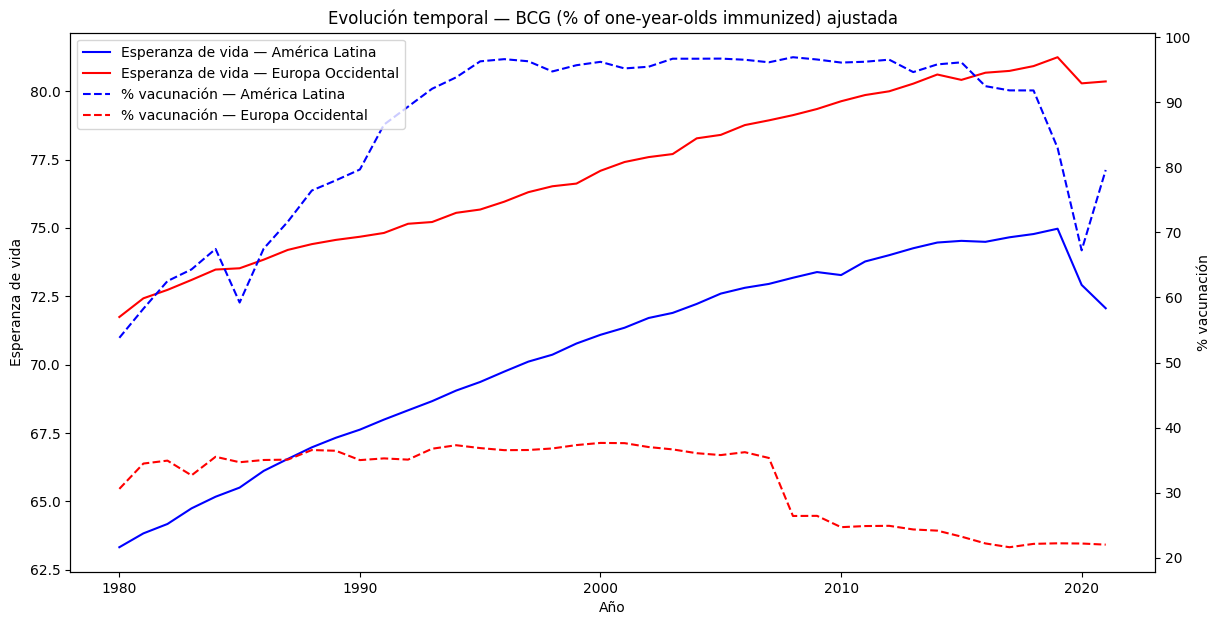


Gráficos para: HepB3 (% of one-year-olds immunized) ajustada



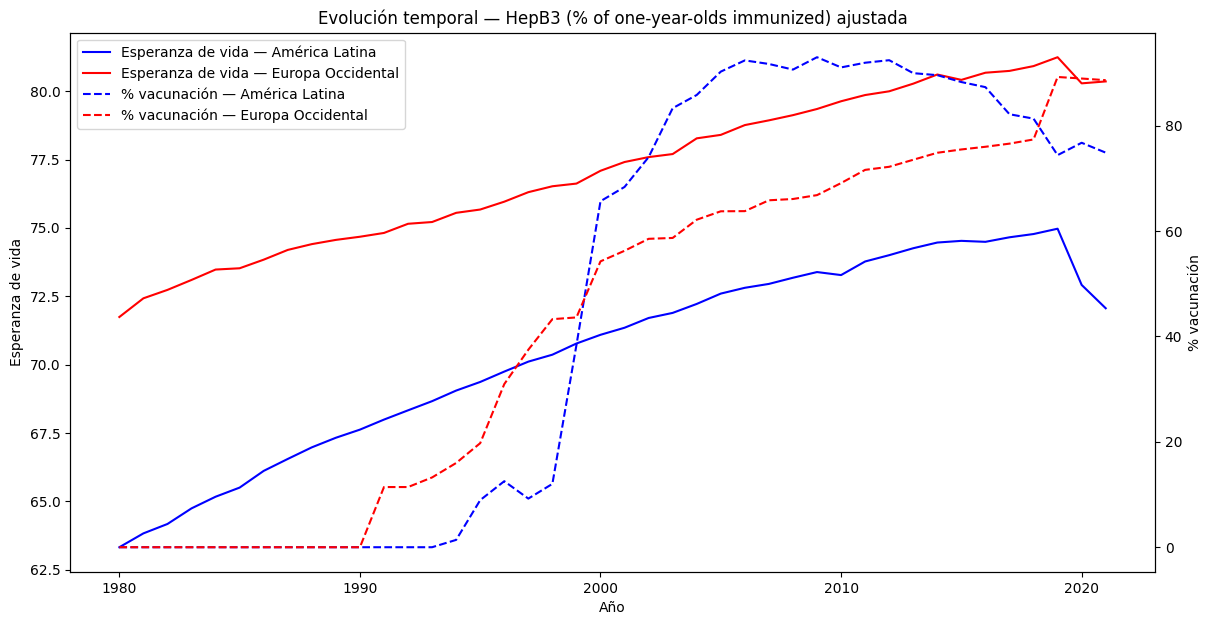


Gráficos para: Hib3 (% of one-year-olds immunized) ajustada



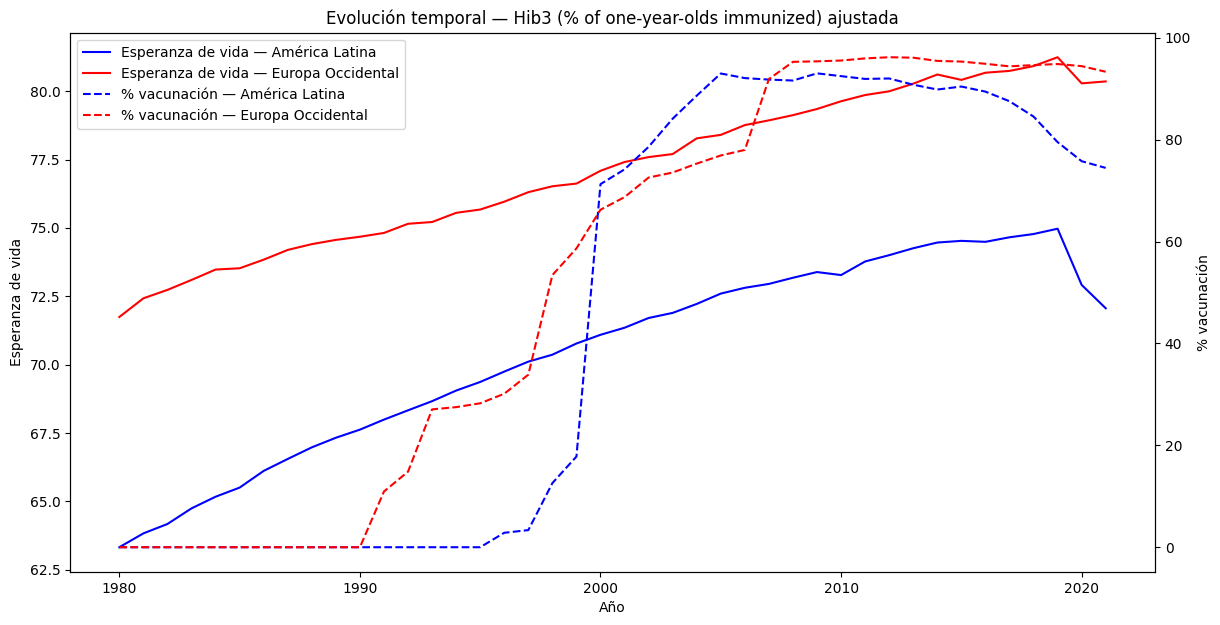


Gráficos para: IPV1 (% of one-year-olds immunized) ajustada



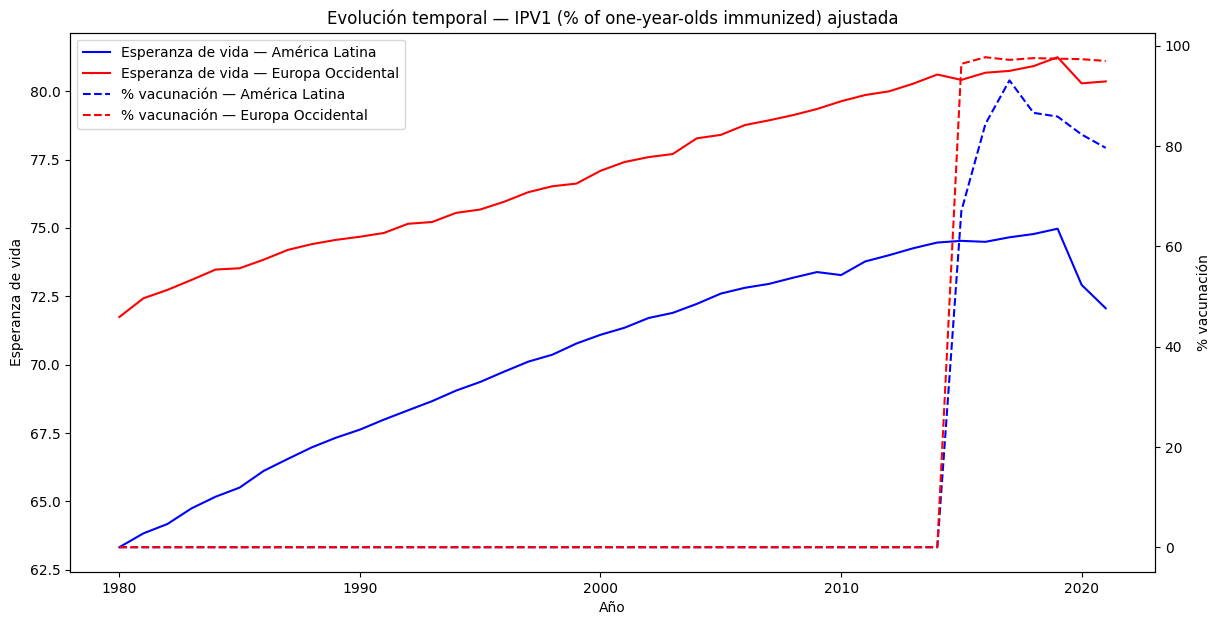


Gráficos para: MCV1 (% of one-year-olds immunized) ajustada



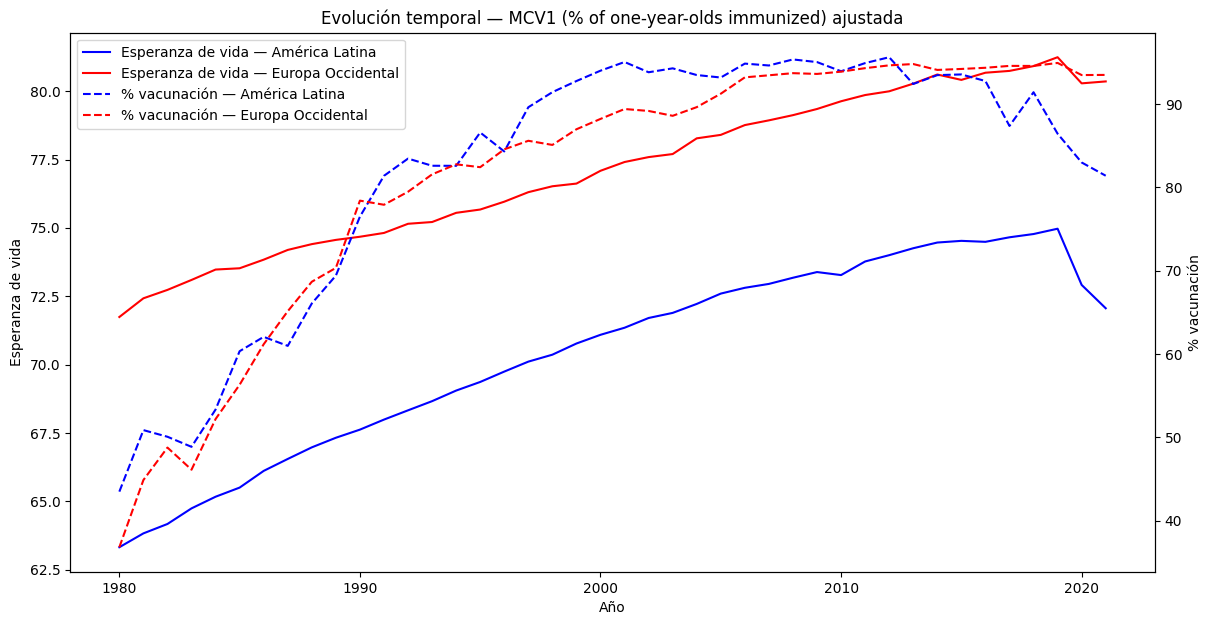


Gráficos para: PCV3 (% of one-year-olds immunized) ajustada



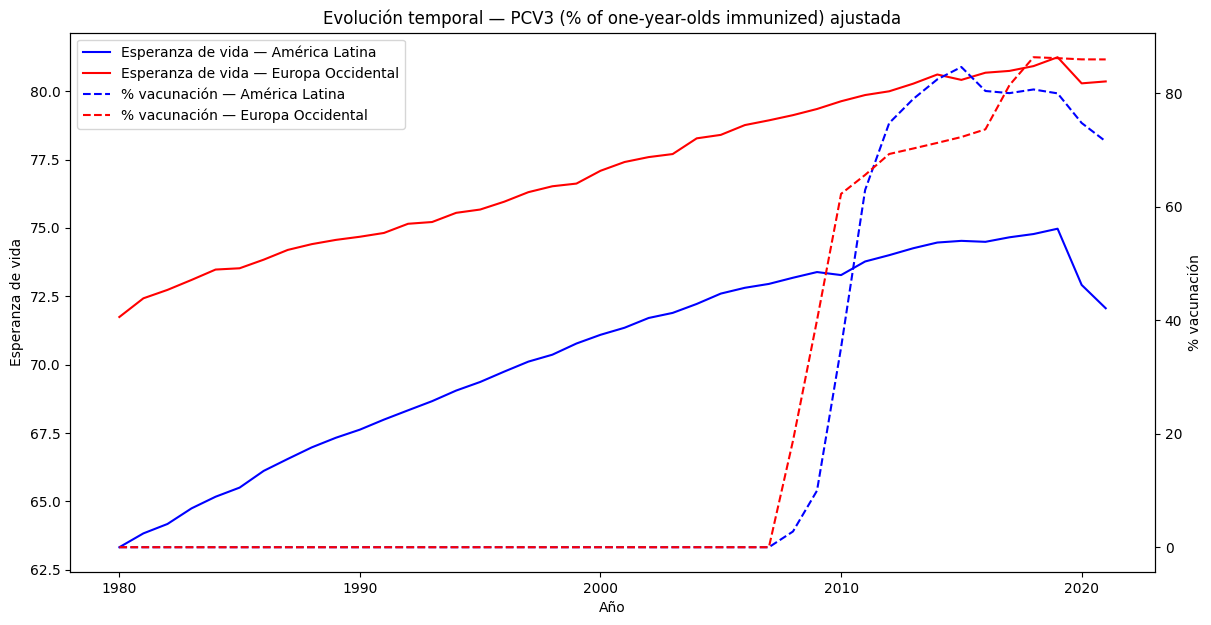


Gráficos para: Pol3 (% of one-year-olds immunized) ajustada



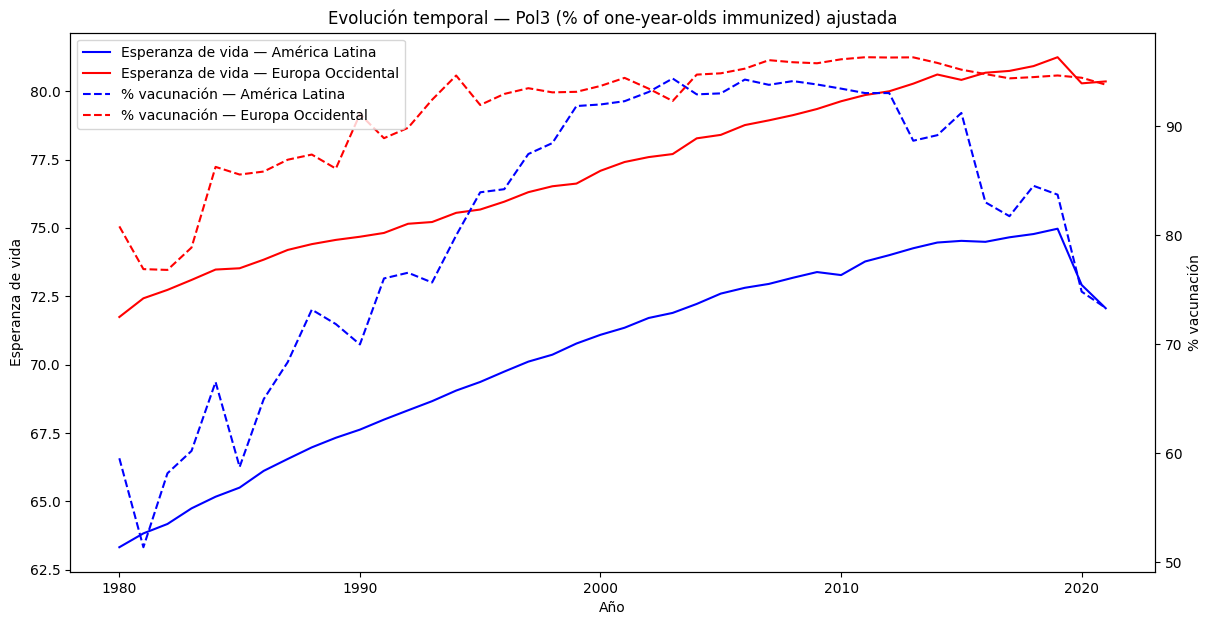


Gráficos para: RCV1 (% of one-year-olds immunized) ajustada



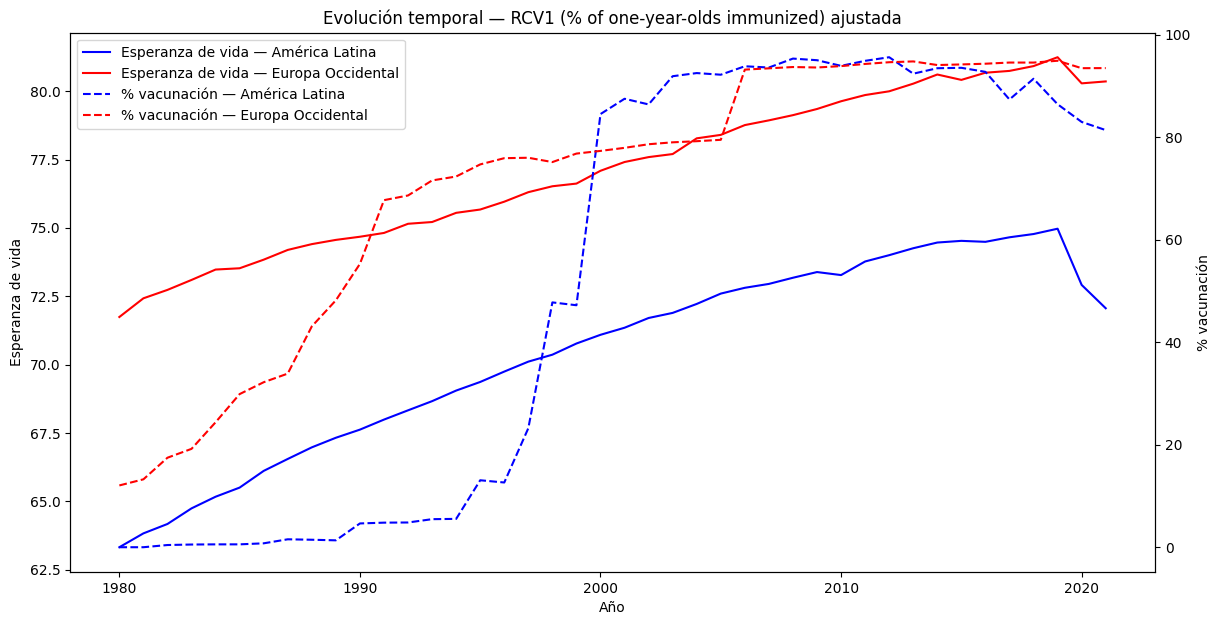


Gráficos para: RotaC (% of one-year-olds immunized) ajustada



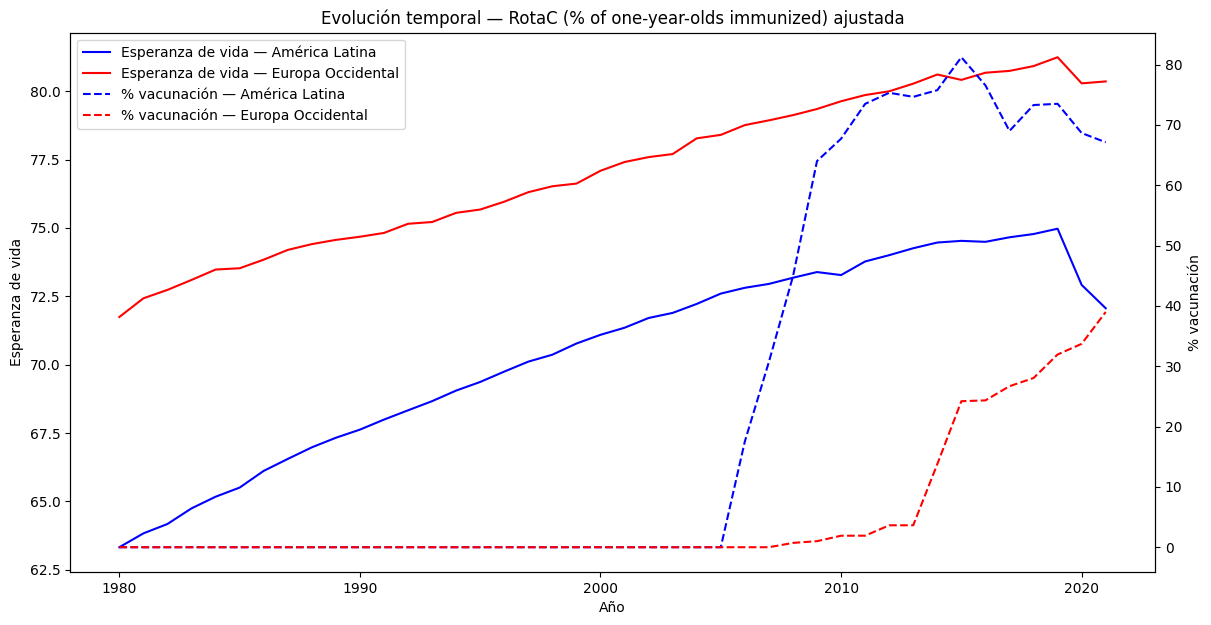


Gráficos para: YFV (% of one-year-olds immunized) ajustada



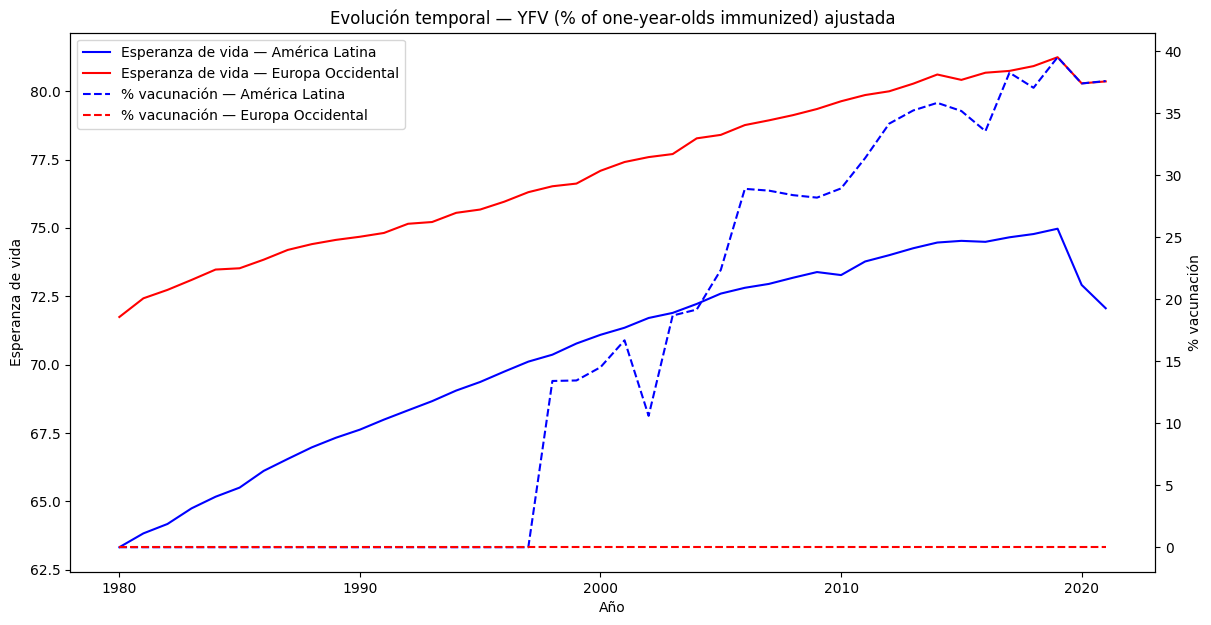


Gráficos para: DTP3 (% of one-year-olds immunized) ajustada



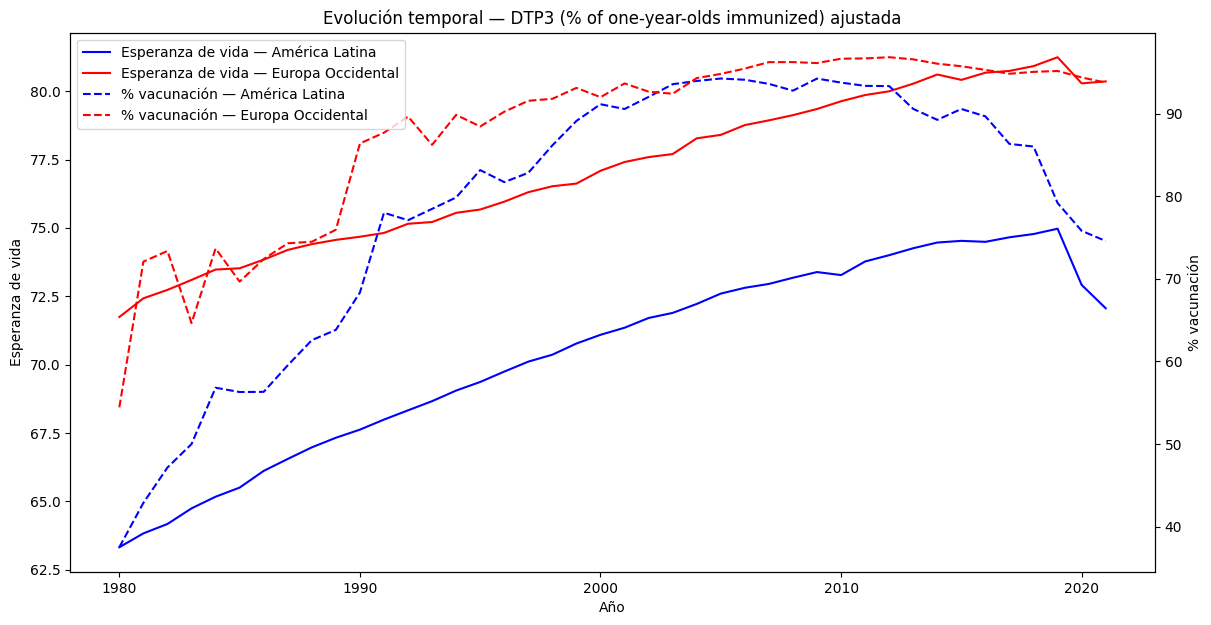


Gráficos para: promedio_cobertura_todas_las_vacunas



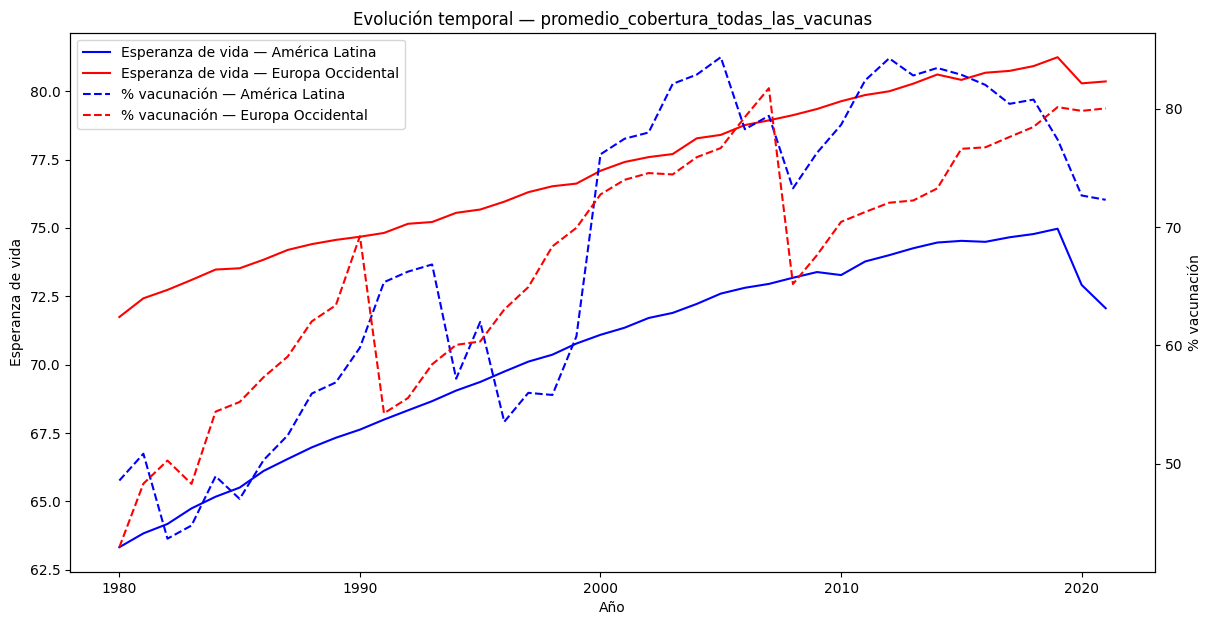


=== HEATMAP FINAL DE CORRELACIONES ===



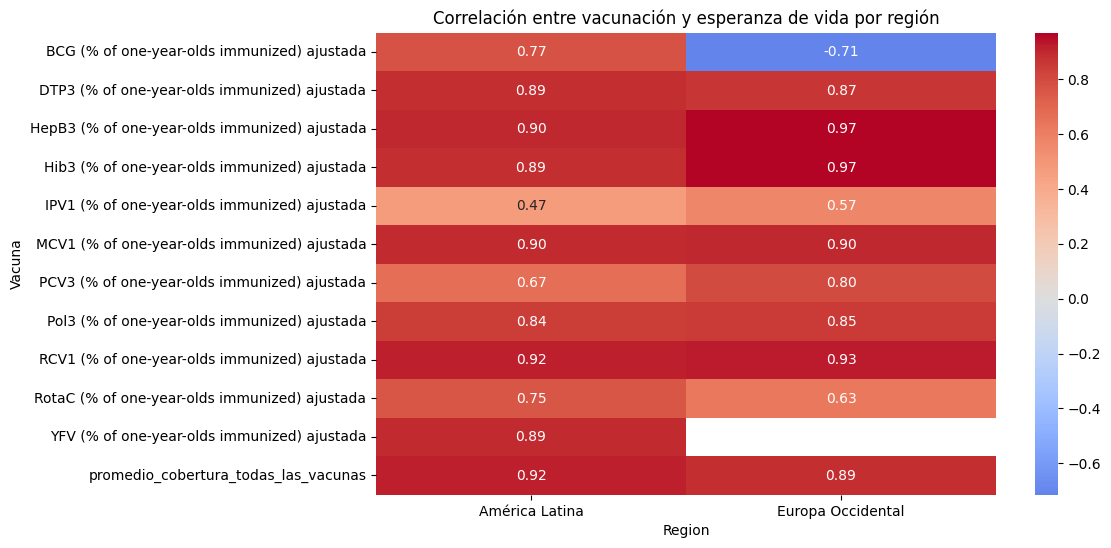

In [64]:
graficar_vacunas(df_regional_limpia,cobertura_de_vacunas_a_graficar)

## Generación del Excel para Dashboard por paises

In [65]:
df_para_dashboard = df_analisis.fillna(0)


In [66]:
df_para_dashboard

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),...,Hib3 (% of one-year-olds immunized) ajustada,IPV1 (% of one-year-olds immunized) ajustada,MCV1 (% of one-year-olds immunized) ajustada,PCV3 (% of one-year-olds immunized) ajustada,Pol3 (% of one-year-olds immunized) ajustada,RCV1 (% of one-year-olds immunized) ajustada,RotaC (% of one-year-olds immunized) ajustada,YFV (% of one-year-olds immunized) ajustada,DTP3 (% of one-year-olds immunized) ajustada,esperanza_vida_ajustada
0,Argentina,ARG,1980,68.5642,62.0,0.0,0.0,0.0,61.0,0.0,...,0.000000,0.000000,4.947675,0.0,2.676611,0.000000,0.000000,0.000000,3.568814,5.561202
1,Argentina,ARG,1981,68.9762,70.0,0.0,0.0,0.0,77.0,0.0,...,0.000000,0.000000,6.205869,0.0,3.223828,0.000000,0.000000,0.000000,3.949189,5.559185
2,Argentina,ARG,1982,68.9368,77.0,0.0,0.0,0.0,67.0,0.0,...,0.000000,0.000000,5.368116,0.0,3.845815,0.000000,0.000000,0.000000,4.647026,5.523295
3,Argentina,ARG,1983,69.2668,70.0,0.0,0.0,0.0,67.0,0.0,...,0.000000,0.000000,5.337103,0.0,6.293002,0.000000,0.000000,0.000000,4.859154,5.517672
4,Argentina,ARG,1984,69.1953,78.0,0.0,0.0,0.0,79.0,0.0,...,0.000000,0.000000,6.257567,0.0,5.703099,0.000000,0.000000,0.000000,4.911002,5.480940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,94.0,66.0,66.0,70.0,96.0,0.0,...,3.286096,3.485253,4.779776,0.0,3.933357,4.779776,0.896208,4.132514,3.286096,3.581994
2054,Venezuela,VEN,2018,71.9788,92.0,60.0,60.0,32.0,74.0,0.0,...,2.887447,1.539972,3.561184,0.0,2.550578,3.561184,0.000000,1.684344,2.887447,3.463916
2055,Venezuela,VEN,2019,72.1614,91.0,64.0,64.0,55.0,93.0,0.0,...,2.965244,2.548257,4.308870,0.0,2.872580,4.308870,0.000000,3.706555,2.965244,3.343377
2056,Venezuela,VEN,2020,71.0949,82.0,54.0,54.0,68.0,76.0,0.0,...,2.441300,3.074229,3.435903,0.0,2.802974,3.435903,0.000000,3.707159,2.441300,3.214147


In [67]:
df_para_dashboard.to_excel("Esperanza de vida para dashboard.xlsx", index=False)

In [120]:
df_para_dashboard_final = df_para_dashboard.drop(columns=df_regional_limpia.columns[2:13])


In [121]:
df_para_dashboard_final

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,BCG (% of one-year-olds immunized),HepB3 (% of one-year-olds immunized),Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population,pobl_con_dato,Ponderacion poblacion en región,esperanza_vida_ajustada
0,Argentina,ARG,1980,68.5642,62.0,0.0,0.0,0.0,61.0,0.0,33.0,0.0,0.0,0.0,44.0,América Latina,28011596.0,345355646.0,0.081109,5.561202
1,Argentina,ARG,1981,68.9762,70.0,0.0,0.0,0.0,77.0,0.0,40.0,0.0,0.0,0.0,49.0,América Latina,28463959.0,353169711.0,0.080596,5.559185
2,Argentina,ARG,1982,68.9368,77.0,0.0,0.0,0.0,67.0,0.0,48.0,0.0,0.0,0.0,58.0,América Latina,28924262.0,361006616.0,0.080121,5.523295
3,Argentina,ARG,1983,69.2668,70.0,0.0,0.0,0.0,67.0,0.0,79.0,0.0,0.0,0.0,61.0,América Latina,29391332.0,368967813.0,0.079658,5.517672
4,Argentina,ARG,1984,69.1953,78.0,0.0,0.0,0.0,79.0,0.0,72.0,0.0,0.0,0.0,62.0,América Latina,29863093.0,377013037.0,0.079210,5.480940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,94.0,66.0,66.0,70.0,96.0,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0,613893036.0,0.049789,3.581994
2054,Venezuela,VEN,2018,71.9788,92.0,60.0,60.0,32.0,74.0,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0,619389977.0,0.048124,3.463916
2055,Venezuela,VEN,2019,72.1614,91.0,64.0,64.0,55.0,93.0,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0,624582095.0,0.046332,3.343377
2056,Venezuela,VEN,2020,71.0949,82.0,54.0,54.0,68.0,76.0,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0,629164917.0,0.045209,3.214147


In [123]:
df_para_dashboard_final_1 = df_para_dashboard_final.drop(df_para_dashboard_final.columns[4:9], axis=1)
df_para_dashboard_final_1



,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region,Population,pobl_con_dato,Ponderacion poblacion en región,esperanza_vida_ajustada
0,Argentina,ARG,1980,68.5642,0.0,33.0,0.0,0.0,0.0,44.0,América Latina,28011596.0,345355646.0,0.081109,5.561202
1,Argentina,ARG,1981,68.9762,0.0,40.0,0.0,0.0,0.0,49.0,América Latina,28463959.0,353169711.0,0.080596,5.559185
2,Argentina,ARG,1982,68.9368,0.0,48.0,0.0,0.0,0.0,58.0,América Latina,28924262.0,361006616.0,0.080121,5.523295
3,Argentina,ARG,1983,69.2668,0.0,79.0,0.0,0.0,0.0,61.0,América Latina,29391332.0,368967813.0,0.079658,5.517672
4,Argentina,ARG,1984,69.1953,0.0,72.0,0.0,0.0,0.0,62.0,América Latina,29863093.0,377013037.0,0.079210,5.480940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,0.0,79.0,96.0,18.0,83.0,66.0,América Latina,30565323.0,613893036.0,0.049789,3.581994
2054,Venezuela,VEN,2018,71.9788,0.0,53.0,74.0,0.0,35.0,60.0,América Latina,29807592.0,619389977.0,0.048124,3.463916
2055,Venezuela,VEN,2019,72.1614,0.0,62.0,93.0,0.0,80.0,64.0,América Latina,28938098.0,624582095.0,0.046332,3.343377
2056,Venezuela,VEN,2020,71.0949,0.0,62.0,76.0,0.0,82.0,54.0,América Latina,28444077.0,629164917.0,0.045209,3.214147


In [125]:
df_para_dashboard_final_2 = df_para_dashboard_final_1.drop(df_para_dashboard_final_1.columns[4:10], axis=1)
df_para_dashboard_final_2

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,Region,Population,pobl_con_dato,Ponderacion poblacion en región,esperanza_vida_ajustada
0,Argentina,ARG,1980,68.5642,América Latina,28011596.0,345355646.0,0.081109,5.561202
1,Argentina,ARG,1981,68.9762,América Latina,28463959.0,353169711.0,0.080596,5.559185
2,Argentina,ARG,1982,68.9368,América Latina,28924262.0,361006616.0,0.080121,5.523295
3,Argentina,ARG,1983,69.2668,América Latina,29391332.0,368967813.0,0.079658,5.517672
4,Argentina,ARG,1984,69.1953,América Latina,29863093.0,377013037.0,0.079210,5.480940
...,...,...,...,...,...,...,...,...,...
2053,Venezuela,VEN,2017,71.9430,América Latina,30565323.0,613893036.0,0.049789,3.581994
2054,Venezuela,VEN,2018,71.9788,América Latina,29807592.0,619389977.0,0.048124,3.463916
2055,Venezuela,VEN,2019,72.1614,América Latina,28938098.0,624582095.0,0.046332,3.343377
2056,Venezuela,VEN,2020,71.0949,América Latina,28444077.0,629164917.0,0.045209,3.214147


In [127]:
df_para_dashboard_final_2['Year'] = df_para_dashboard_final_2['Year'].astype('object')
df_integrado['Year'] = df_integrado['Year'].astype('object')

df_para_dashboard_merge = df_para_dashboard_final_2.merge(
    df_integrado,
    on=['Code', 'Year'],
    how='left'
)


In [128]:
df_para_dashboard_merge

,Entity_x,Code,Year,Period life expectancy at birth - Sex: all - Age: 0_x,Region_x,Population,pobl_con_dato,Ponderacion poblacion en región,esperanza_vida_ajustada,Entity_y,...,Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region_y
0,Argentina,ARG,1980,68.5642,América Latina,28011596.0,345355646.0,0.081109,5.561202,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Argentina,ARG,1981,68.9762,América Latina,28463959.0,353169711.0,0.080596,5.559185,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Argentina,ARG,1982,68.9368,América Latina,28924262.0,361006616.0,0.080121,5.523295,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,ARG,1983,69.2668,América Latina,29391332.0,368967813.0,0.079658,5.517672,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,1984,69.1953,América Latina,29863093.0,377013037.0,0.079210,5.480940,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,Venezuela,VEN,2017,71.9430,América Latina,30565323.0,613893036.0,0.049789,3.581994,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986,Venezuela,VEN,2018,71.9788,América Latina,29807592.0,619389977.0,0.048124,3.463916,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987,Venezuela,VEN,2019,72.1614,América Latina,28938098.0,624582095.0,0.046332,3.343377,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988,Venezuela,VEN,2020,71.0949,América Latina,28444077.0,629164917.0,0.045209,3.214147,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
df_para_dashboard_merge_final = df_para_dashboard_merge.fillna(0)


In [130]:
df_para_dashboard_merge_final

,Entity_x,Code,Year,Period life expectancy at birth - Sex: all - Age: 0_x,Region_x,Population,pobl_con_dato,Ponderacion poblacion en región,esperanza_vida_ajustada,Entity_y,...,Hib3 (% of one-year-olds immunized),IPV1 (% of one-year-olds immunized),MCV1 (% of one-year-olds immunized),PCV3 (% of one-year-olds immunized),Pol3 (% of one-year-olds immunized),RCV1 (% of one-year-olds immunized),RotaC (% of one-year-olds immunized),YFV (% of one-year-olds immunized),DTP3 (% of one-year-olds immunized),Region_y
0,Argentina,ARG,1980,68.5642,América Latina,28011596.0,345355646.0,0.081109,5.561202,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,Argentina,ARG,1981,68.9762,América Latina,28463959.0,353169711.0,0.080596,5.559185,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,Argentina,ARG,1982,68.9368,América Latina,28924262.0,361006616.0,0.080121,5.523295,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,Argentina,ARG,1983,69.2668,América Latina,29391332.0,368967813.0,0.079658,5.517672,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,Argentina,ARG,1984,69.1953,América Latina,29863093.0,377013037.0,0.079210,5.480940,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,Venezuela,VEN,2017,71.9430,América Latina,30565323.0,613893036.0,0.049789,3.581994,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1986,Venezuela,VEN,2018,71.9788,América Latina,29807592.0,619389977.0,0.048124,3.463916,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1987,Venezuela,VEN,2019,72.1614,América Latina,28938098.0,624582095.0,0.046332,3.343377,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1988,Venezuela,VEN,2020,71.0949,América Latina,28444077.0,629164917.0,0.045209,3.214147,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [133]:
df_integrado_pob_final = df_integrado_pob.fillna(0)

In [134]:
df_integrado_pob_final.to_excel("df_para_dashboard_entregable.xlsx", index=False)